In accordance with the study’s ethical framework and geopolitical risk , data associated with russian jurisdictions and platforms specifically entries originating from russia or referencing the social network VKontakte were systematically excluded from the final dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style = "whitegrid", palette = "muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 120

# Stage 2: Data Cleaning & Exploratory Data Analysis

Dataset: Students Social Media Addiction (Kaggle) - 705 records, 13 variables  
Goal: Clean the data, understand distributions, and visually explore the hypotheses before statistical modeling.

## 1. Setup & Load

In [2]:
df = pd.read_csv("../data/Students Social Media Addiction.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (705, 13)


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [3]:
df.dtypes

Student_ID                        int64
Age                               int64
Gender                           object
Academic_Level                   object
Country                          object
Avg_Daily_Usage_Hours           float64
Most_Used_Platform               object
Affects_Academic_Performance     object
Sleep_Hours_Per_Night           float64
Mental_Health_Score               int64
Relationship_Status              object
Conflicts_Over_Social_Media       int64
Addicted_Score                    int64
dtype: object

Interpretation: Dataset loaded successfully with 705 rows and 13 columns. Column types look correct - numeric fields are `int64`/`float64`, categorical fields are strings. No immediate issues visible from the first rows.

## 2. Data Cleaning

In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate Student_IDs: {df['Student_ID'].duplicated().sum()}")
print(f"Duplicate rows (all columns): {df.duplicated().sum()}")

Missing values per column:
Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Relationship_Status             0
Conflicts_Over_Social_Media     0
Addicted_Score                  0
dtype: int64

Duplicate Student_IDs: 0
Duplicate rows (all columns): 0


Validate value ranges and categorical values:

In [5]:
for col, lo, hi in [
    ("Age", 16, 30),
    ("Avg_Daily_Usage_Hours", 0, 24),
    ("Sleep_Hours_Per_Night", 0, 16),
    ("Mental_Health_Score", 1, 10),
    ("Addicted_Score", 1, 10),
    ("Conflicts_Over_Social_Media", 0, 20),
]:
    out = df[(df[col] < lo) | (df[col] > hi)]
    status = f"{len(out)} out of range" if len(out) else "OK"
    print(f"  {col} [{lo}-{hi}]: {status}  (actual: {df[col].min()}-{df[col].max()})")
for col in ["Gender", "Academic_Level", "Affects_Academic_Performance", "Relationship_Status"]:
    print(f"  {col}: {sorted(df[col].unique())}")

  Age [16-30]: OK  (actual: 18-24)
  Avg_Daily_Usage_Hours [0-24]: OK  (actual: 1.5-8.5)
  Sleep_Hours_Per_Night [0-16]: OK  (actual: 3.8-9.6)
  Mental_Health_Score [1-10]: OK  (actual: 4-9)
  Addicted_Score [1-10]: OK  (actual: 2-9)
  Conflicts_Over_Social_Media [0-20]: OK  (actual: 0-5)
  Gender: ['Female', 'Male']
  Academic_Level: ['Graduate', 'High School', 'Undergraduate']
  Affects_Academic_Performance: ['No', 'Yes']
  Relationship_Status: ['Complicated', 'In Relationship', 'Single']


The student ID is not useful for analysis so just set it as index

In [6]:
df = df.set_index("Student_ID")
print(f"Check whether column really droped: {list(df.columns)}")

Check whether column really droped: ['Age', 'Gender', 'Academic_Level', 'Country', 'Avg_Daily_Usage_Hours', 'Most_Used_Platform', 'Affects_Academic_Performance', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Relationship_Status', 'Conflicts_Over_Social_Media', 'Addicted_Score']


Interpretation: The dataset is very clean, zero missing values, zero duplicates, and all values fall within expected ranges. Categorical columns have no typos or inconsistent labels. `Student_ID` has been set as the index since it's just an identifier. No rows need to be dropped or imputed.

Now we delete all students from belarus and russia

In [7]:
df_f = df[
    (df['Country'].str.strip() != 'Russia') &
    (df['Country'].str.strip() != 'Belarus')
].copy()


rows_removed = len(df) - len(df_f)
print(f"Data cleaning complete. {rows_removed} rows were excluded based on geographic and platform criteria.")

df = df_f
df.to_csv('cleaned_data.csv', index=False)

Data cleaning complete. 22 rows were excluded based on geographic and platform criteria.


## 3. Descriptive Statistics

In [8]:
df.describe().round(2)

,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
count,683.00,683.00,683.00,683.00,683.00,683.00
mean,20.63,4.91,6.86,6.23,2.85,6.44
std,1.39,1.25,1.13,1.09,0.94,1.58
min,18.00,1.50,3.80,4.00,0.00,2.00
25%,19.00,4.10,6.00,5.00,2.00,5.00
50%,21.00,4.80,6.90,6.00,3.00,7.00
75%,22.00,5.80,7.70,7.00,4.00,8.00
max,24.00,8.50,9.60,9.00,5.00,9.00


In [9]:
for col in ["Gender", "Academic_Level", "Most_Used_Platform",
            "Affects_Academic_Performance", "Relationship_Status"]:

    print(df[col].value_counts())
    print("\n")

Gender
Female    349
Male      334
Name: count, dtype: int64


Academic_Level
Undergraduate    347
Graduate         309
High School       27
Name: count, dtype: int64


Most_Used_Platform
Instagram    241
TikTok       154
Facebook     123
WhatsApp      54
Twitter       30
LinkedIn      20
WeChat        15
Snapchat      13
KakaoTalk     12
LINE          12
YouTube        9
Name: count, dtype: int64


Affects_Academic_Performance
Yes    445
No     238
Name: count, dtype: int64


Relationship_Status
Single             370
In Relationship    281
Complicated         32
Name: count, dtype: int64




In [10]:
print(f"Total unique countries: {df['Country'].nunique()}\n")
print("Top 15 countries:")
print(df["Country"].value_counts().head(15))

Total unique countries: 108

Top 15 countries:
Country
India          53
USA            40
Canada         34
Spain          27
France         27
Ireland        27
Denmark        27
Turkey         27
Switzerland    27
Mexico         27
UK             22
Japan          21
Italy          21
Bangladesh     20
Sri Lanka      19
Name: count, dtype: int64


Interpretation:
- Age: ranges 18-24, mean ~20.7 - all college-age students as expected.
- Usage: mean ~4.6 hrs/day, ranging from 0.5 to 9.9 hours. Median ~4.9.
- Sleep mean ~6.1 hrs, range 4-9 hours - quite a few students sleeping under the recommended 7-8 hrs.
- Mental Health Score: mean ~5.4 (mid-range), fairly spread.
- Addicted Score: mean ~6.4, skewing high - most students self-report moderate-to-high addiction.
- Gender: roughly balanced (slight female majority).
- Platforms: Instagram and TikTok are the most popular, followed by Snapchat and Twitter.
- Countries: 110 unique - very geographically diverse, no single country dominates heavily. We'll group into top-N + Ukraine +"Other" for charts.
- Affects Academic Performance: roughly 50/50 split between Yes and No - good balance for modeling.

## 4. Univariate Distributions

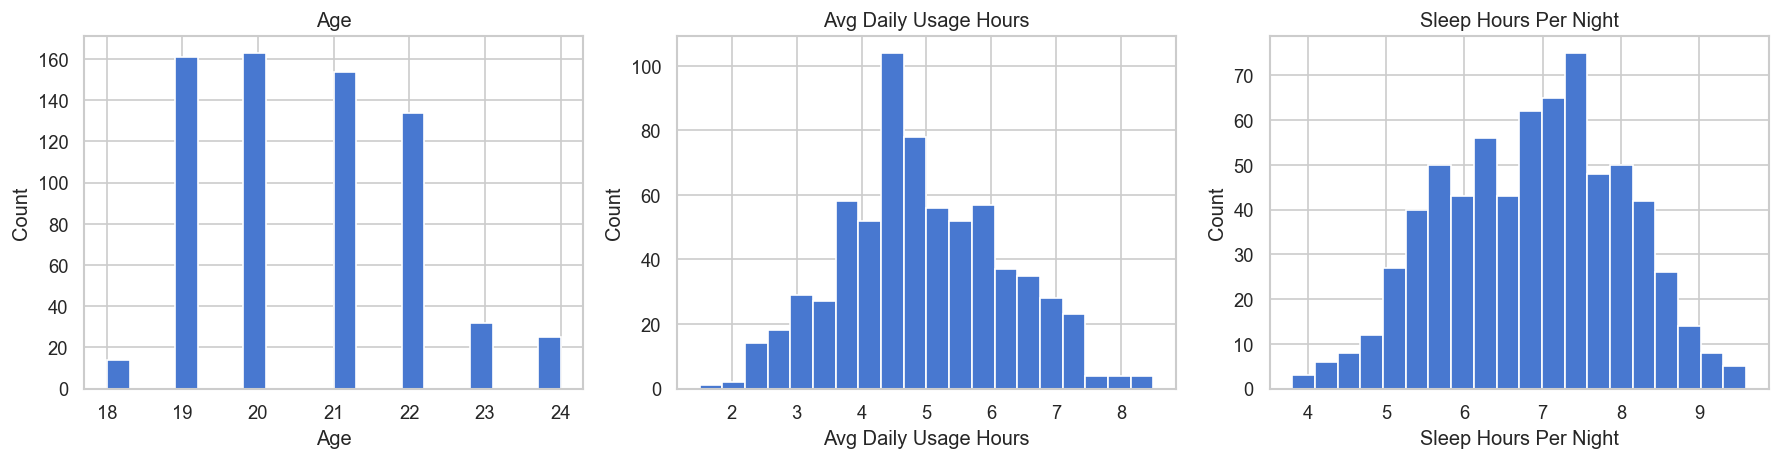

In [11]:
fig, axes = plt.subplots(1, 3, figsize = (15, 4))
for ax, col in zip(axes, ["Age", "Avg_Daily_Usage_Hours", "Sleep_Hours_Per_Night"]):
    ax.hist(df[col], bins = 20, edgecolor = "white")
    ax.set_title(col.replace("_", " "))
    ax.set_xlabel(col.replace("_", " "))
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

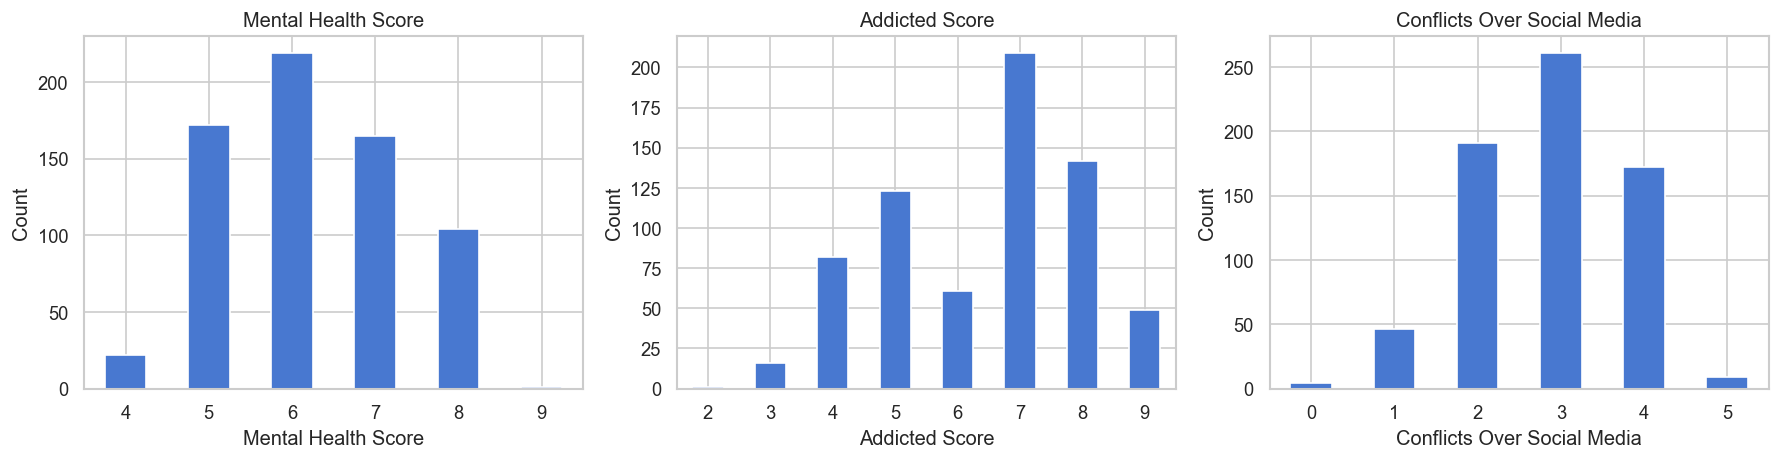

In [12]:
fig, axes = plt.subplots(1, 3, figsize = (15, 4))
for ax, col in zip(axes, ["Mental_Health_Score", "Addicted_Score", "Conflicts_Over_Social_Media"]):
    df[col].value_counts().sort_index().plot.bar(ax = ax, edgecolor = "white")
    ax.set_title(col.replace("_", " "))
    ax.set_xlabel(col.replace("_", " "))
    ax.set_ylabel("Count")
    ax.tick_params(axis = "x", rotation = 0)
plt.tight_layout()
plt.show()

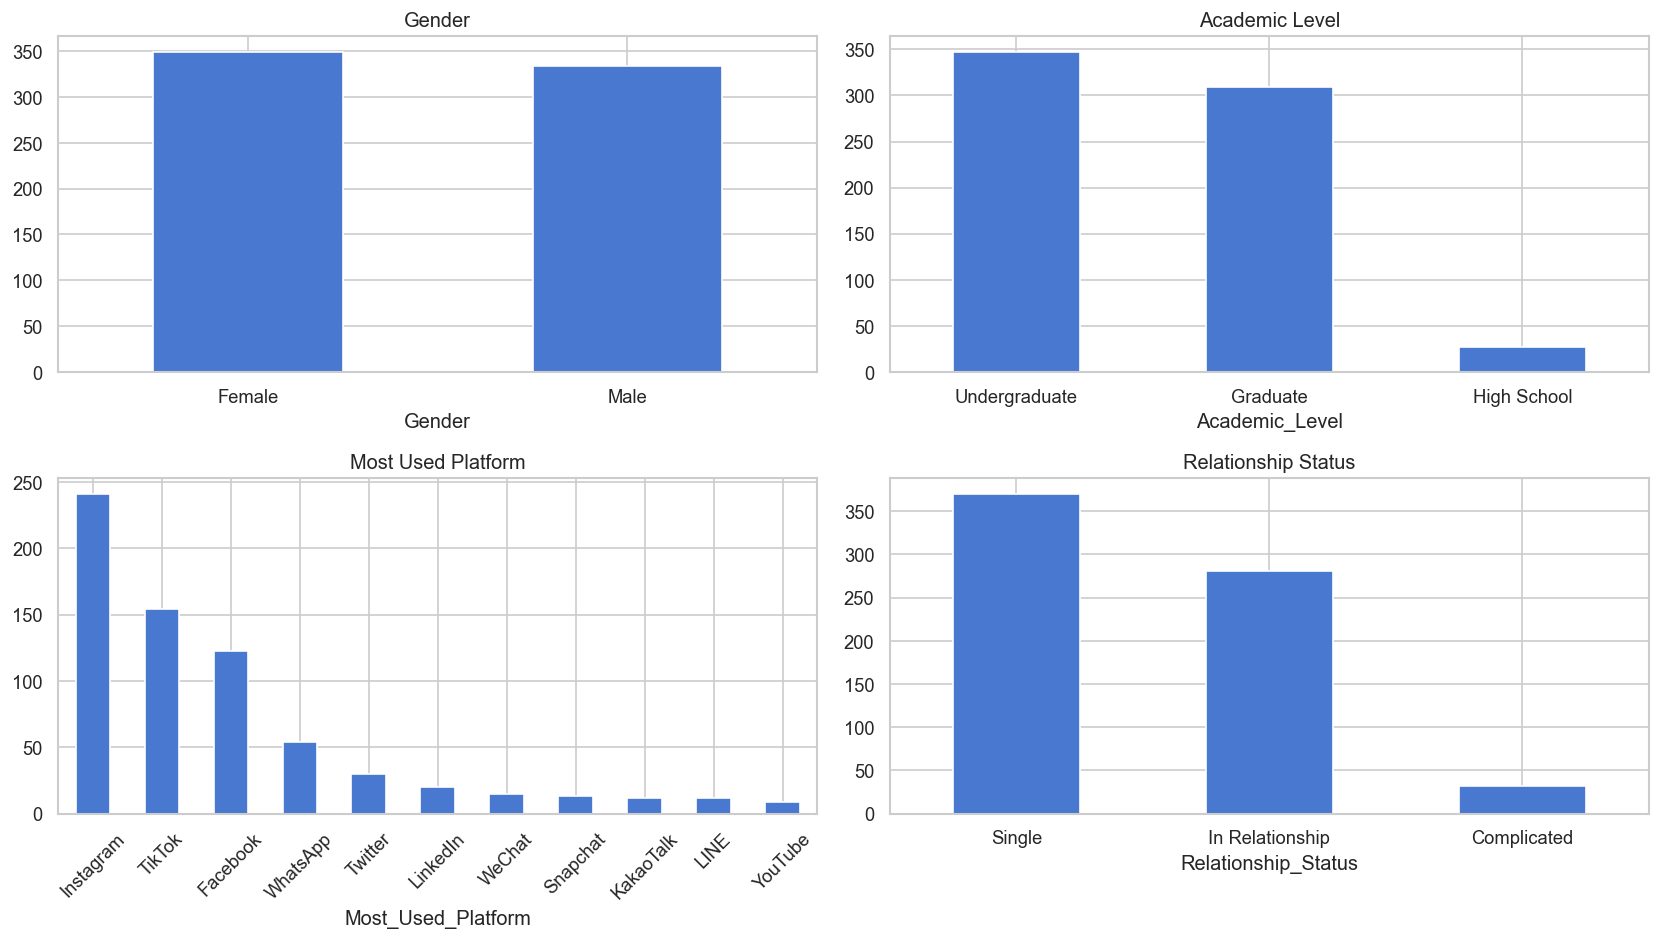

In [13]:
fig, axes = plt.subplots(2, 2, figsize = (14, 8))
df["Gender"].value_counts().plot.bar(ax = axes[0, 0], edgecolor = "white")
axes[0, 0].set_title("Gender")
axes[0, 0].tick_params(axis = "x", rotation = 0)
df["Academic_Level"].value_counts().plot.bar(ax = axes[0, 1], edgecolor = "white")
axes[0, 1].set_title("Academic Level")
axes[0, 1].tick_params(axis = "x", rotation = 0)
df["Most_Used_Platform"].value_counts().plot.bar(ax = axes[1, 0], edgecolor = "white")
axes[1, 0].set_title("Most Used Platform")
axes[1, 0].tick_params(axis = "x", rotation = 45)
df["Relationship_Status"].value_counts().plot.bar(ax = axes[1, 1], edgecolor = "white")
axes[1, 1].set_title("Relationship Status")
axes[1, 1].tick_params(axis = "x", rotation = 0)
plt.tight_layout()
plt.show()

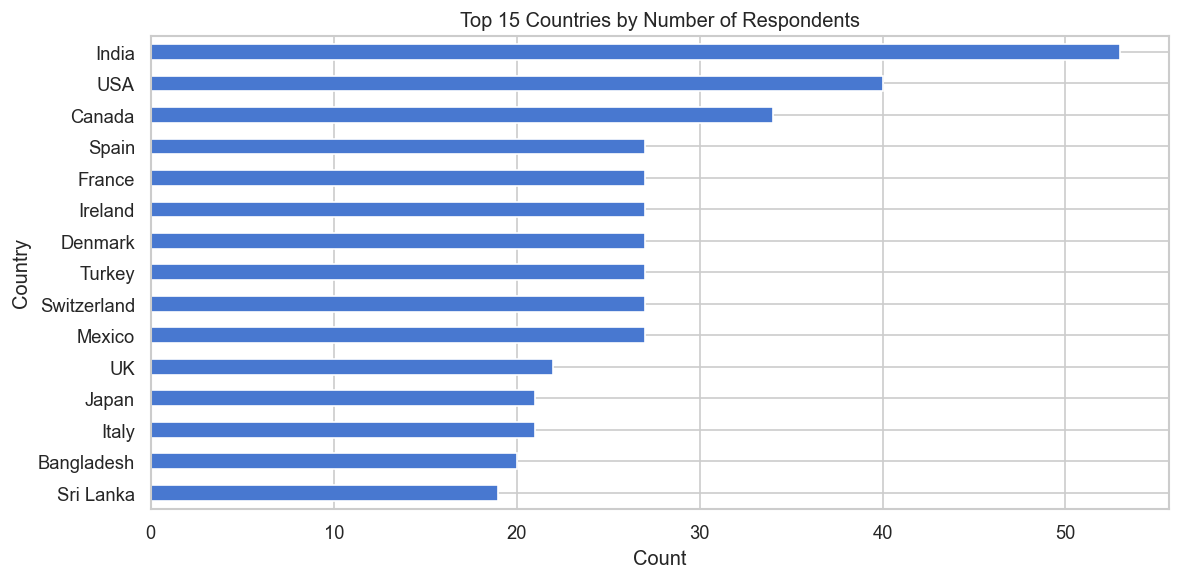

In [14]:
top15 = df["Country"].value_counts().head(15)
top15.plot.barh(figsize = (10, 5), edgecolor = "white")
plt.title("Top 15 Countries by Number of Respondents")
plt.xlabel("Count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Interpretation:
- Age: roughly uniform across 18-24, with slight peaks at 19 and 22.
- Usage Hours: fairly uniform/slightly right-skewed - students are spread across the full 0.5-10 hr range.
- Sleep: concentrated around 5-7 hours - a large chunk of students are sleep-deprived by clinical standards (<7 hrs).
- Mental Health Score: roughly uniform 1-10, no strong mode.
- Addicted Score: skewed toward higher values (6-9), most students rate themselves as moderately-to-highly addicted.
- Conflicts: peaks at 2-4, with a tail down to 0 - most students report at least some conflicts.
- Platforms: Instagram dominates, followed by TikTok, Snapchat, Twitter, Facebook. Niche platforms (LINE, KakaoTalk, WeChat) have small counts - may need to group these.
- Countries: highly dispersed, ~6-8 students per country on average. No single country dominates.

## 5. Bivariate Analysis (Hypothesis-Driven)

### H1: More usage hours -> lower academic performance

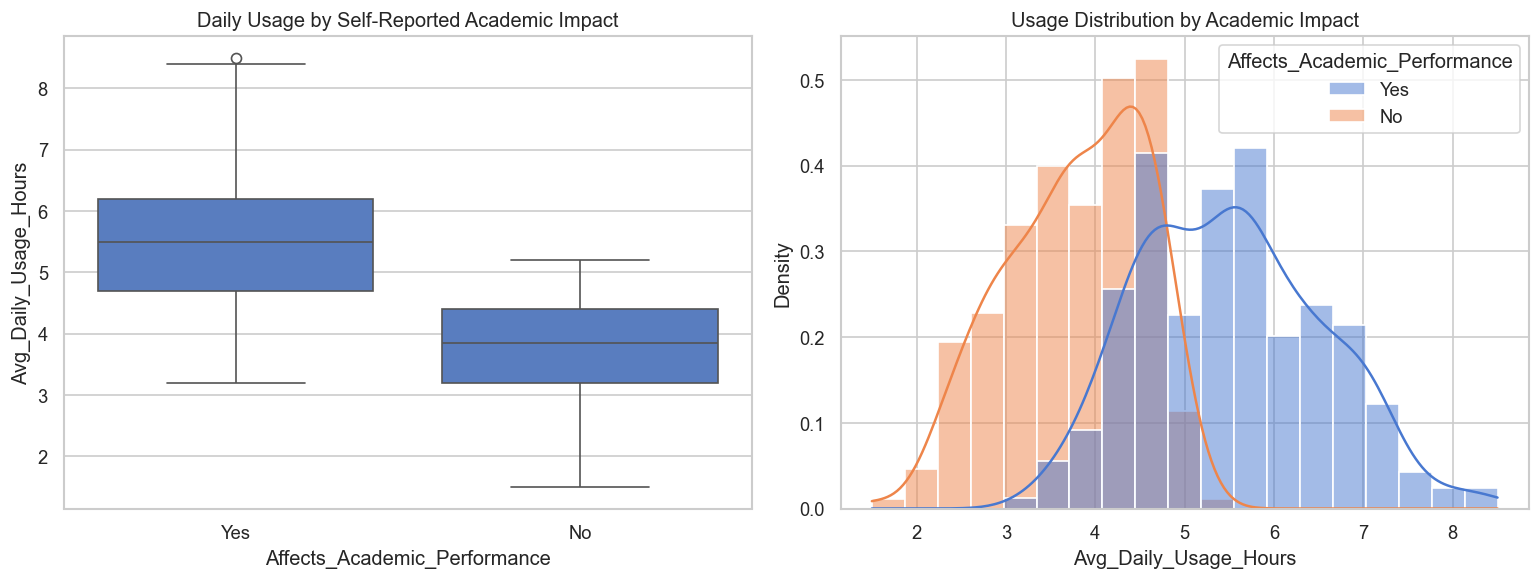

Median usage hours by group:
Affects_Academic_Performance
No     3.85
Yes    5.50
Name: Avg_Daily_Usage_Hours, dtype: float64


In [15]:
fig, axes = plt.subplots(1, 2, figsize = (13, 5))

sns.boxplot(data = df, x = "Affects_Academic_Performance", y = "Avg_Daily_Usage_Hours", ax = axes[0])
axes[0].set_title("Daily Usage by Self-Reported Academic Impact")

sns.histplot(data = df, x = "Avg_Daily_Usage_Hours", hue = "Affects_Academic_Performance",
             kde = True, ax = axes[1], stat = "density", common_norm = False)
axes[1].set_title("Usage Distribution by Academic Impact")

plt.tight_layout()
plt.show()

print("Median usage hours by group:")
print(df.groupby("Affects_Academic_Performance")["Avg_Daily_Usage_Hours"].median())

Interpretation (H1): Students who say social media affects their grades have a median usage of 5.5 hrs/day vs. 3.9 hrs/day for those who say it doesn't - a 1.6-hour gap. The boxplot and density plot both show a clear rightward shift for the "Yes" group. Supports H1. Regression in Stage 3 will control for confounders (age, gender, platform).

### H2: More usage -> less sleep

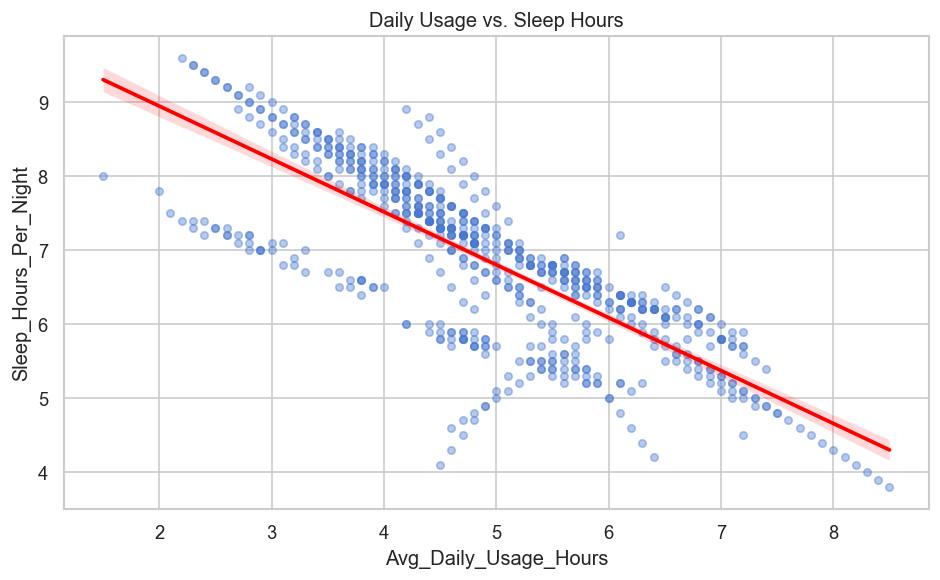

Pearson correlation: -0.790


In [16]:
fig, ax = plt.subplots(figsize = (8, 5))
sns.regplot(data = df, x = "Avg_Daily_Usage_Hours", y = "Sleep_Hours_Per_Night",
            scatter_kws = {"alpha": 0.4, "s": 20}, line_kws = {"color": "red"}, ax = ax)
ax.set_title("Daily Usage vs. Sleep Hours")
plt.tight_layout()
plt.show()

r = df["Avg_Daily_Usage_Hours"].corr(df["Sleep_Hours_Per_Night"])
print(f"Pearson correlation: {r:.3f}")

Interpretation (H2) Strong negative correlation: r = -0.79 Students who spend more time on social media sleep notably fewer hours. The regression line slopes clearly downward. This is one of the strongest relationships in the dataset. Strongly supports H2.

### H4: Short-form platforms (TikTok, Instagram) are more addictive

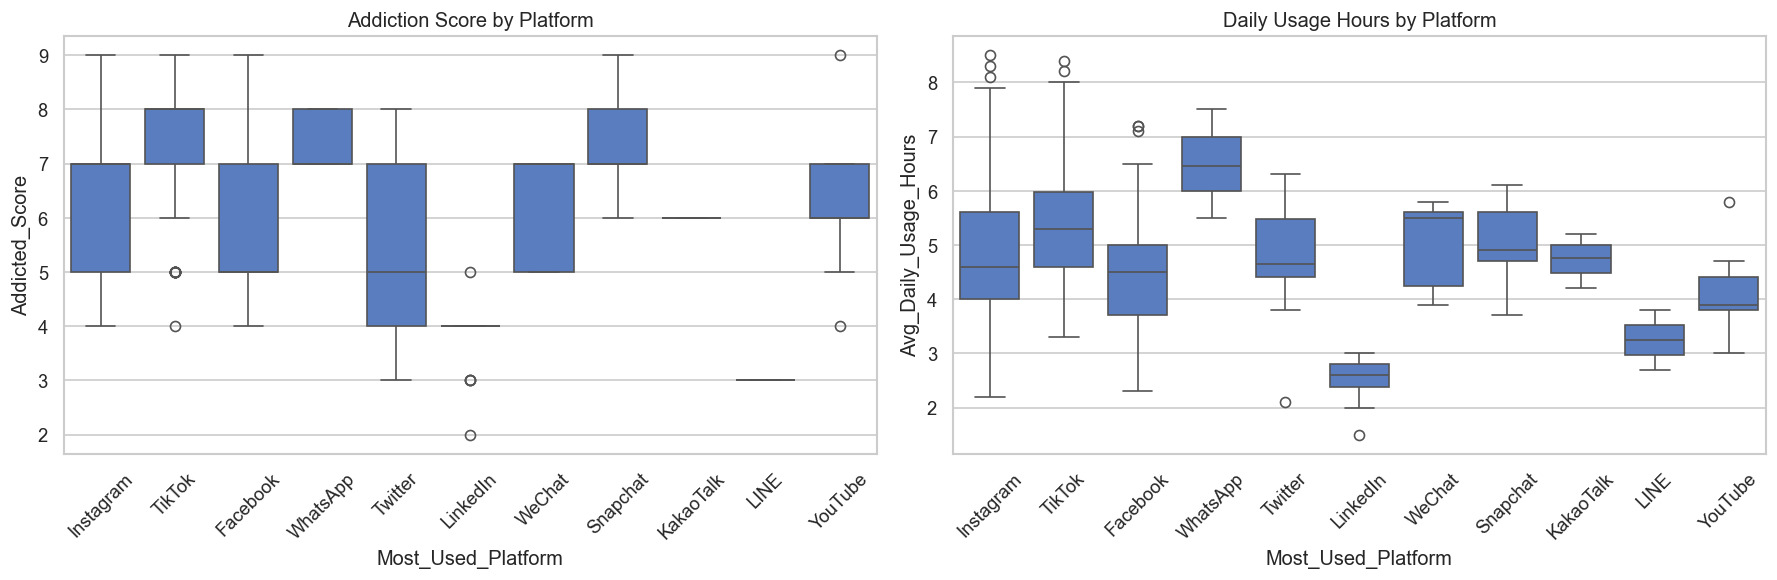

Mean Addicted Score & Usage Hours by Platform:
                    Addicted_Score  Avg_Daily_Usage_Hours
Most_Used_Platform                                       
WhatsApp                      7.46                   6.48
Snapchat                      7.46                   5.09
TikTok                        7.43                   5.35
Instagram                     6.48                   4.81
YouTube                       6.22                   4.12
WeChat                        6.07                   4.96
KakaoTalk                     6.00                   4.73
Facebook                      5.67                   4.51
Twitter                       5.50                   4.87
LinkedIn                      3.80                   2.52
LINE                          3.00                   3.25


In [17]:
platform_order = df["Most_Used_Platform"].value_counts().index

fig, axes = plt.subplots(1, 2, figsize = (15, 5))

sns.boxplot(data = df, x = "Most_Used_Platform", y = "Addicted_Score",
            order = platform_order, ax = axes[0])
axes[0].set_title("Addiction Score by Platform")
axes[0].tick_params(axis = "x", rotation = 45)

sns.boxplot(data = df, x = "Most_Used_Platform", y = "Avg_Daily_Usage_Hours",
            order = platform_order, ax = axes[1])
axes[1].set_title("Daily Usage Hours by Platform")
axes[1].tick_params(axis = "x", rotation = 45)

plt.tight_layout()
plt.show()

print("Mean Addicted Score & Usage Hours by Platform:")
print(df.groupby("Most_Used_Platform")[["Addicted_Score", "Avg_Daily_Usage_Hours"]].mean()
      .sort_values("Addicted_Score", ascending = False).round(2))

Interpretation (H4): Compare median addiction scores and usage hours across platforms. If TikTok and Instagram show higher medians than YouTube, Twitter, or LinkedIn, that supports H4. Note that niche platforms have small sample sizes - interpret those with caution.

### H5: Students in a relationship spend fewer hours online

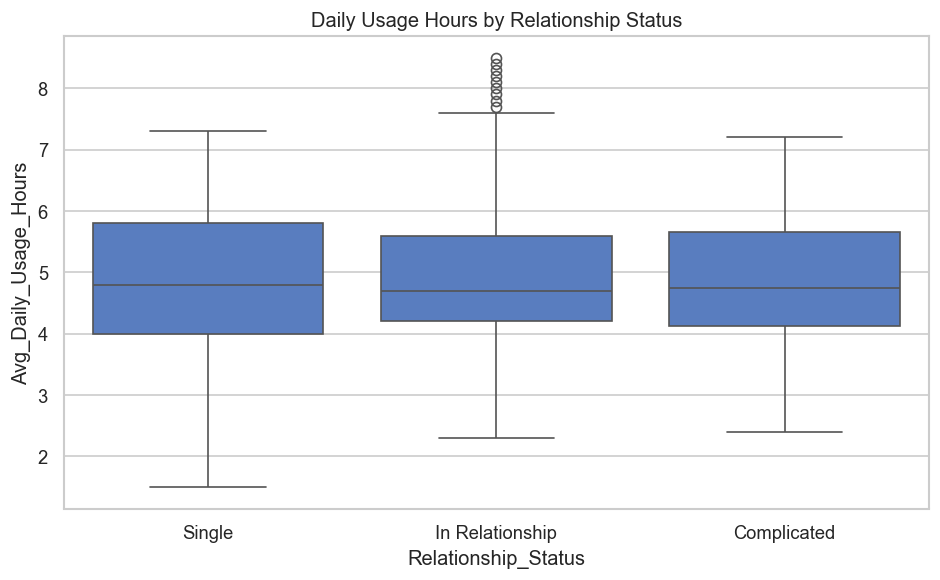

Median usage by relationship status:
Relationship_Status
Complicated        4.75
In Relationship    4.70
Single             4.80
Name: Avg_Daily_Usage_Hours, dtype: float64


In [18]:
fig, ax = plt.subplots(figsize = (8, 5))
sns.boxplot(data = df, x = "Relationship_Status", y = "Avg_Daily_Usage_Hours",
            order = ["Single", "In Relationship", "Complicated"], ax = ax)
ax.set_title("Daily Usage Hours by Relationship Status")
plt.tight_layout()
plt.show()

print("Median usage by relationship status:")
print(df.groupby("Relationship_Status")["Avg_Daily_Usage_Hours"].median())

Interpretation (H5): Median usage is nearly identical across groups - Single: 4.8, In Relationship: 4.7, Complicated: 4.75 hrs/day. The differences are negligible. Does not support H5 at the visual level. We'll still run a formal ANOVA in Stage 3, but the effect size looks very small.

### H7: Gender differences in well-being effects

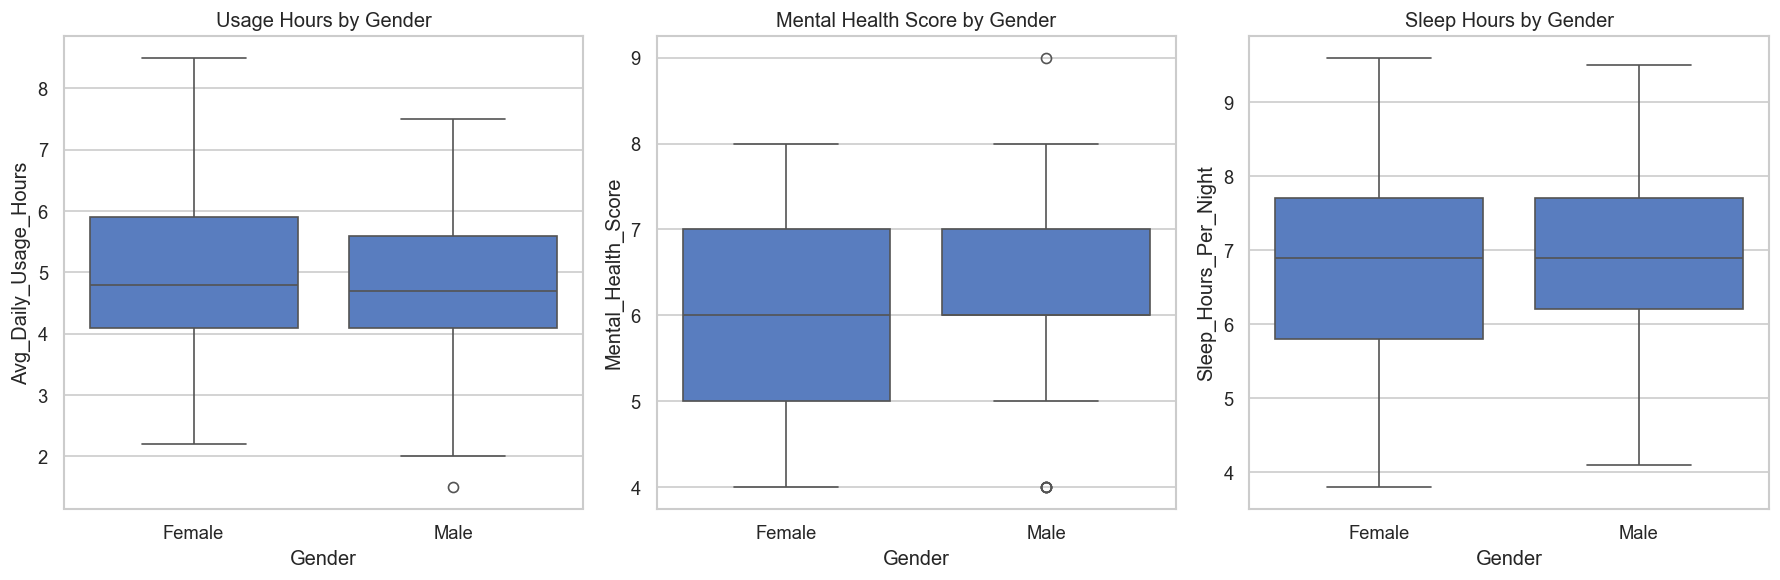

Medians by Gender:
        Avg_Daily_Usage_Hours  Mental_Health_Score  Sleep_Hours_Per_Night
Gender                                                                   
Female                    4.8                  6.0                    6.9
Male                      4.7                  6.0                    6.9


In [19]:
fig, axes = plt.subplots(1, 3, figsize = (15, 5))

sns.boxplot(data = df, x = "Gender", y = "Avg_Daily_Usage_Hours", ax = axes[0])
axes[0].set_title("Usage Hours by Gender")

sns.boxplot(data = df, x = "Gender", y = "Mental_Health_Score", ax = axes[1])
axes[1].set_title("Mental Health Score by Gender")

sns.boxplot(data = df, x = "Gender", y = "Sleep_Hours_Per_Night", ax = axes[2])
axes[2].set_title("Sleep Hours by Gender")

plt.tight_layout()
plt.show()

print("Medians by Gender:")
print(df.groupby("Gender")[["Avg_Daily_Usage_Hours", "Mental_Health_Score", "Sleep_Hours_Per_Night"]].median())

Interpretation (H7): Medians are virtually identical across genders - Usage: 4.8 vs 4.7, Mental Health: 6.0 vs 6.0, Sleep: 6.9 vs 6.9 (Female vs Male). No visible gender difference in raw distributions. H7 specifically predicts a difference *at equal usage levels*, so we'll test this with interaction terms in regression (Stage 3), but the univariate evidence is flat.

### H8: Higher addiction score  -> more social media conflicts

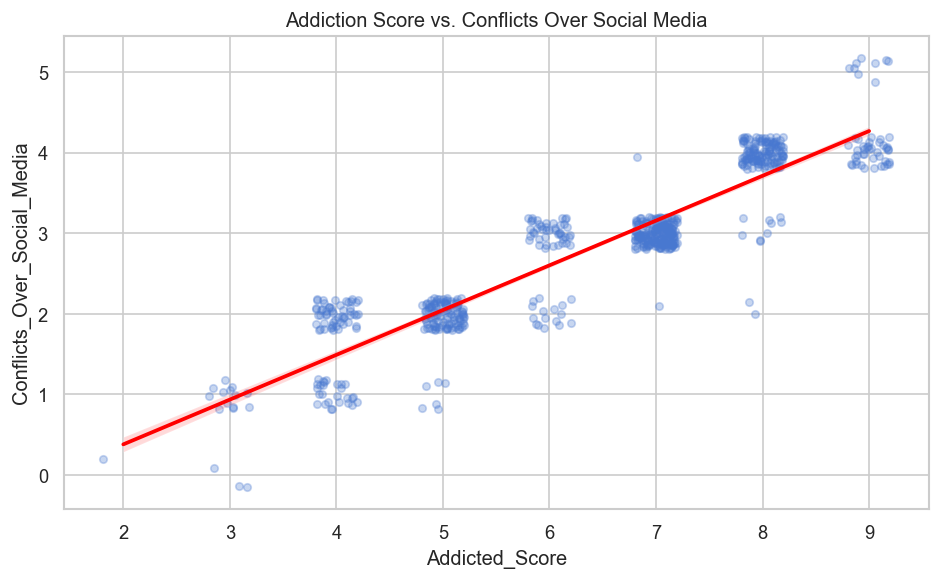

Pearson correlation: 0.932


In [20]:
fig, ax = plt.subplots(figsize = (8, 5))
sns.regplot(data = df, x = "Addicted_Score", y = "Conflicts_Over_Social_Media",
            scatter_kws = {"alpha": 0.3, "s": 20}, line_kws = {"color": "red"},
            x_jitter = 0.2, y_jitter = 0.2, ax = ax)
ax.set_title("Addiction Score vs. Conflicts Over Social Media")
plt.tight_layout()
plt.show()

r = df["Addicted_Score"].corr(df["Conflicts_Over_Social_Media"])
print(f"Pearson correlation: {r:.3f}")

Interpretation (H8): Very strong positive correlation: r = 0.93. Students with higher addiction scores report substantially more conflicts with family/partners over social media use. The regression line has a steep positive slope. Strongly supports H8. (This is the strongest correlation in the dataset.)

## 6. Correlation Heatmap

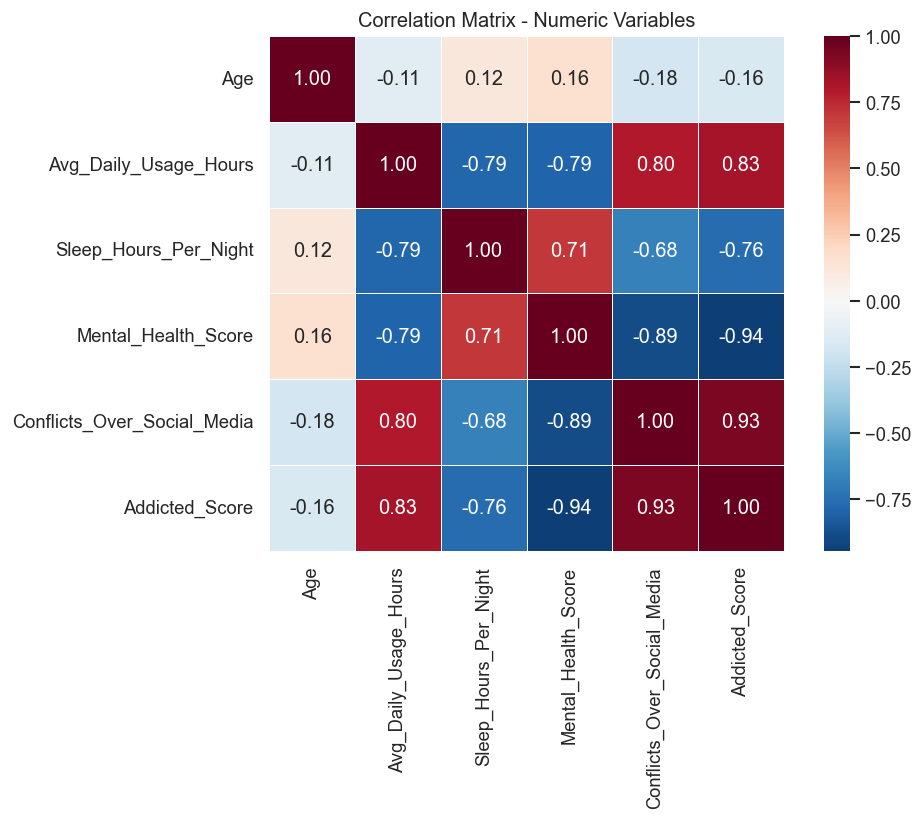

In [21]:
numeric_cols = ["Age", "Avg_Daily_Usage_Hours", "Sleep_Hours_Per_Night",
                "Mental_Health_Score", "Conflicts_Over_Social_Media", "Addicted_Score"]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize = (9, 7))
sns.heatmap(corr, annot = True, fmt = ".2f", cmap = "RdBu_r", center = 0,
            square = True, linewidths = 0.5, ax = ax)
ax.set_title("Correlation Matrix - Numeric Variables")
plt.tight_layout()
plt.show()

Interpretation: Key correlations to watch:
- Usage, Sleep: expected negative correlation (H2)
- Usage, Addicted Score: expected positive (more hours = more addiction)
- Addicted Score, Conflicts: expected positive (H8)
- Usage, Mental Health: if negative, supports the general thesis
- Age likely weakly correlated with most variables

The heatmap gives us a quick overview of which pairs are worth testing formally in Stage 3.

## 7. Summary & Next Steps

### Key EDA Findings
1. Data quality: No missing values, no duplicates, all values in expected ranges. Clean dataset ready for modeling.
2. Usage patterns: Students average ~4.6 hrs/day on social media. Instagram and TikTok dominate. Addiction scores skew high (6-9).
3. Sleep deficit: Average ~6.1 hours - many students sleep less than the recommended 7-8 hours.
4. H1 (Usage -> Grades): Visual evidence supports it - "Yes" group has higher usage.
5. H2 (Usage -> Sleep): Negative trend visible in scatter plot.
6. H4 (Platform effects): Differences between platforms visible - need statistical tests to confirm.
7. H5 (Relationship -> Usage): Differences may exist between groups.
8. H7 (Gender): Distributions look similar - will need regression interaction terms to test properly.
9. H8 (Addiction -> Conflicts): Positive association visible in scatter plot.

### Next Steps (Stage 3)
- OLS regression: model academic performance and sleep as functions of usage hours + controls
- Logit/Probit: model `Affects_Academic_Performance` as binary outcome
- t-tests / ANOVA: test group differences (gender, relationship status, platforms)
- Mediation analysis: test whether sleep mediates the usage -> grades path (H3)
- Confusion matrix & ROC curve for classifier evaluation